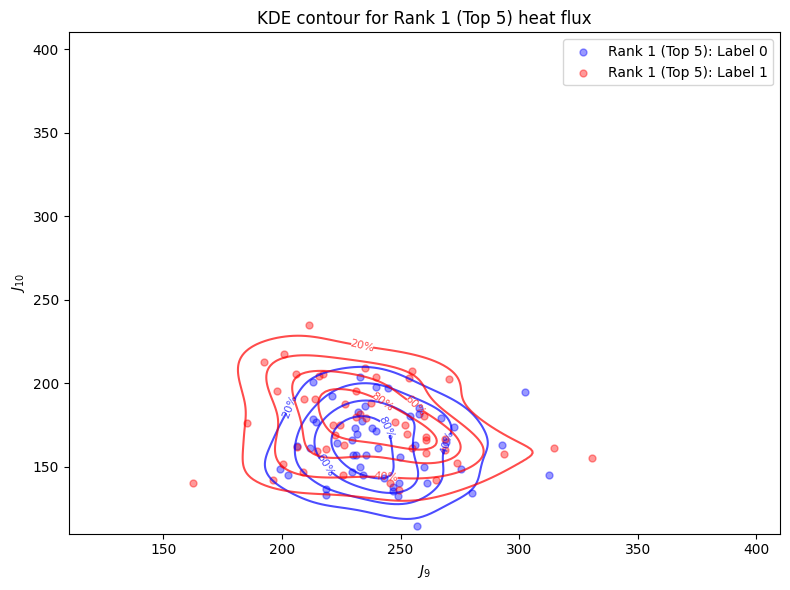

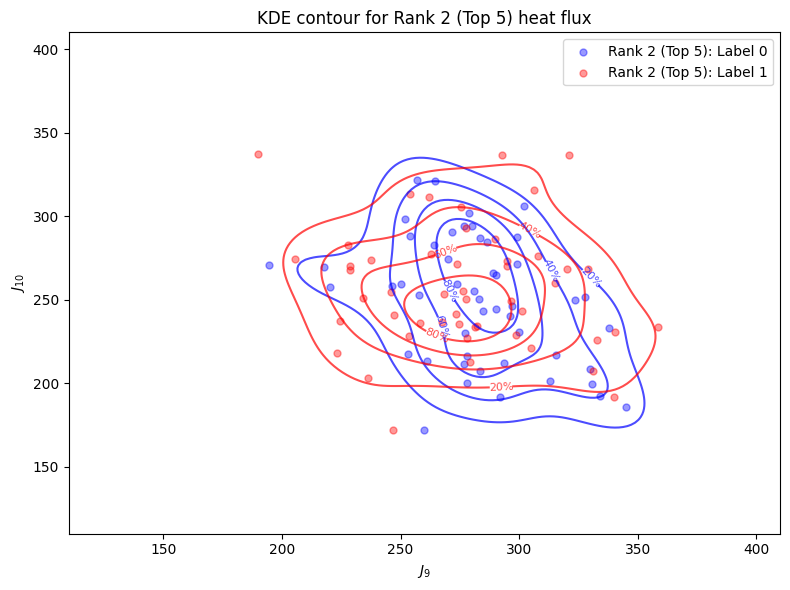

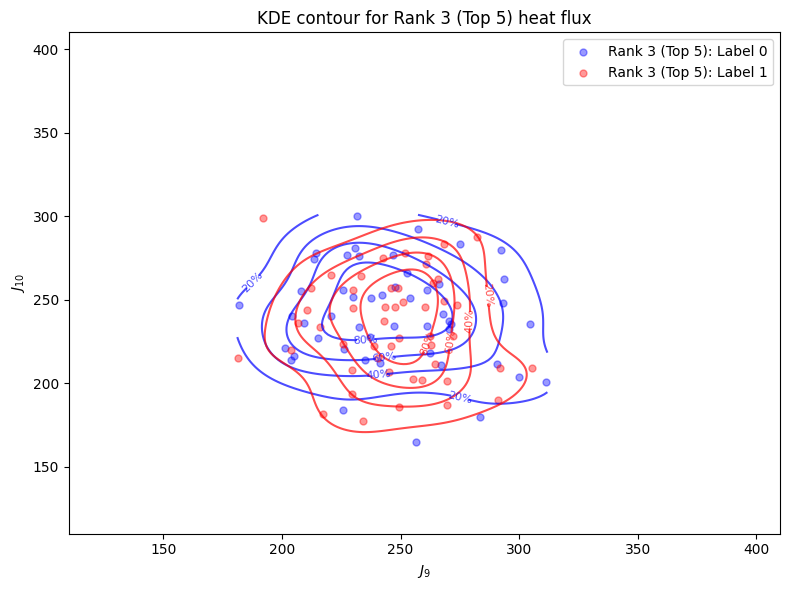

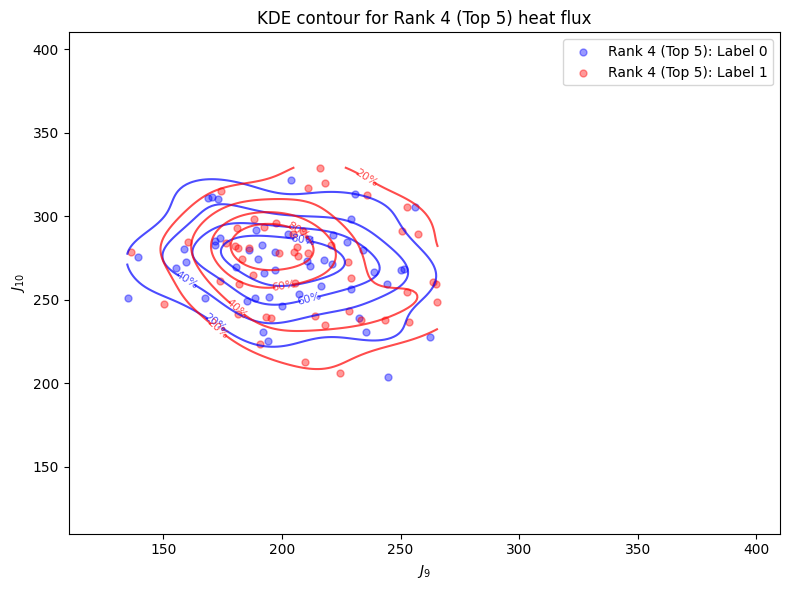

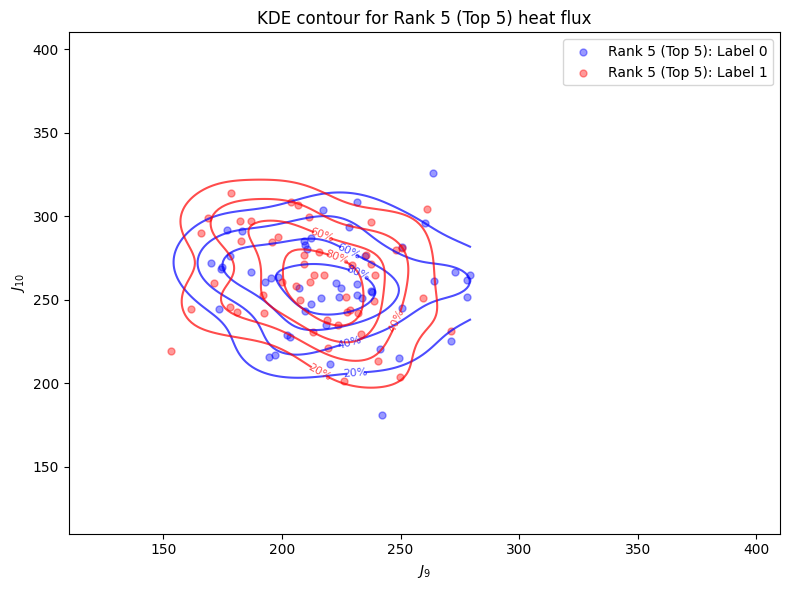

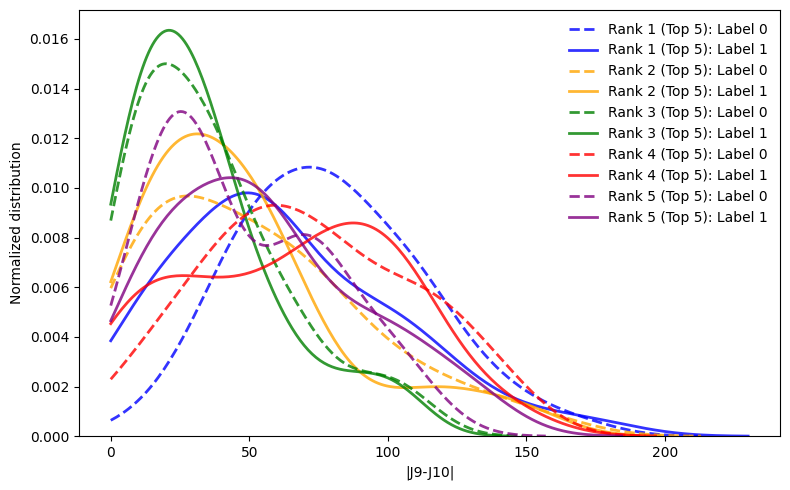

In [22]:
import itertools
import math
import time
import csv
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
from scipy.stats import gaussian_kde

round = 'Round1'
column_names  = ['NP1', 'NP2', 'NP3', 'NP4','NP5', 'NP6', 'NP7', 'NP8','NP9', 'NP10']
hf1 = pd.read_csv(f"heatflux_all_{round}_p1.csv",header=None, names=column_names)
hf2 = pd.read_csv(f"heatflux_all_{round}_p2.csv",header=None, names=column_names)
hf3 = pd.read_csv(f"heatflux_all_{round}_p3.csv",header=None, names=column_names)
hf4 = pd.read_csv(f"heatflux_all_{round}_p4.csv",header=None, names=column_names)
hf5 = pd.read_csv(f"heatflux_all_{round}_p5.csv",header=None, names=column_names)

datasets = [hf1, hf2, hf3, hf4, hf5]

labels = [f"Rank {i} (Top 5)" for i in range(1, 6)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple']

for df, label, base_color in zip(datasets, labels, base_colors):
    fig=plt.figure(figsize=(8, 6))
    x = df.iloc[:, 8].values
    y = df.iloc[:, 9].values

    plt.scatter(x[50:], y[50:], s=25, alpha=0.4, color='blue', label=f'{label}: Label 0')

    plt.scatter(x[:50], y[:50], s=25, alpha=0.4, color='red', label=f'{label}: Label 1')

    kde1 = gaussian_kde(np.vstack([x[:50], y[:50]]))
    kde0 = gaussian_kde(np.vstack([x[50:], y[50:]]))

    xmin, xmax = x.min() - 0.5, x.max() + 0.5
    ymin, ymax = y.min() - 0.5, y.max() + 0.5

    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]

    Z0 = kde0(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled0 = Z0 / Z0.max() * 100
    CS0 = plt.contour(X, Y, Z_scaled0, levels=5, colors='blue', linewidths=1.5, alpha=0.7)
    plt.clabel(CS0, inline=True, fontsize=8, fmt='%.0f%%')

    Z1 = kde1(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled1 = Z1 / Z1.max() * 100
    CS1 = plt.contour(X, Y, Z_scaled1, levels=5, colors='red', linewidths=1.5, alpha=0.7)
    plt.clabel(CS1, inline=True, fontsize=8, fmt='%.0f%%')

    plt.xlabel(r'$J_{9}$')
    plt.ylabel(r'$J_{10}$')
    plt.xlim((110,410))
    plt.ylim((110,410))
    plt.legend()
    plt.title(f'KDE contour for {label} heat flux')
    plt.tight_layout()
    plt.show()

output = pd.DataFrame({
    f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)
    for i, df in enumerate(datasets)
})

fig=plt.figure(figsize=(8, 5))
for i, (label, base_color) in enumerate(zip(labels, base_colors)):
    # Next 50 rows label 0
    sns.kdeplot(output[f"col{i+1}"].iloc[50:], 
                clip=(0, None), 
                label=f'{label}: Label 0', 
                color=base_color,
                fill=False,
                linewidth=2,
                linestyle='--',
                alpha=0.8)
    # First 50 rows label 1
    sns.kdeplot(output[f"col{i+1}"].iloc[:50], 
                clip=(0, None), 
                label=f'{label}: Label 1', 
                color=base_color, 
                fill=False,
                linewidth=2,
                alpha=0.8)

#plt.title('Distribution of |J9-J10|', fontsize=13)
plt.xlabel('|J9-J10|')
plt.ylabel('Normalized distribution')
plt.legend(framealpha=0.0, loc='best')
plt.tight_layout()
plt.show()
#fig.savefig(f"difference.pdf", format="pdf")




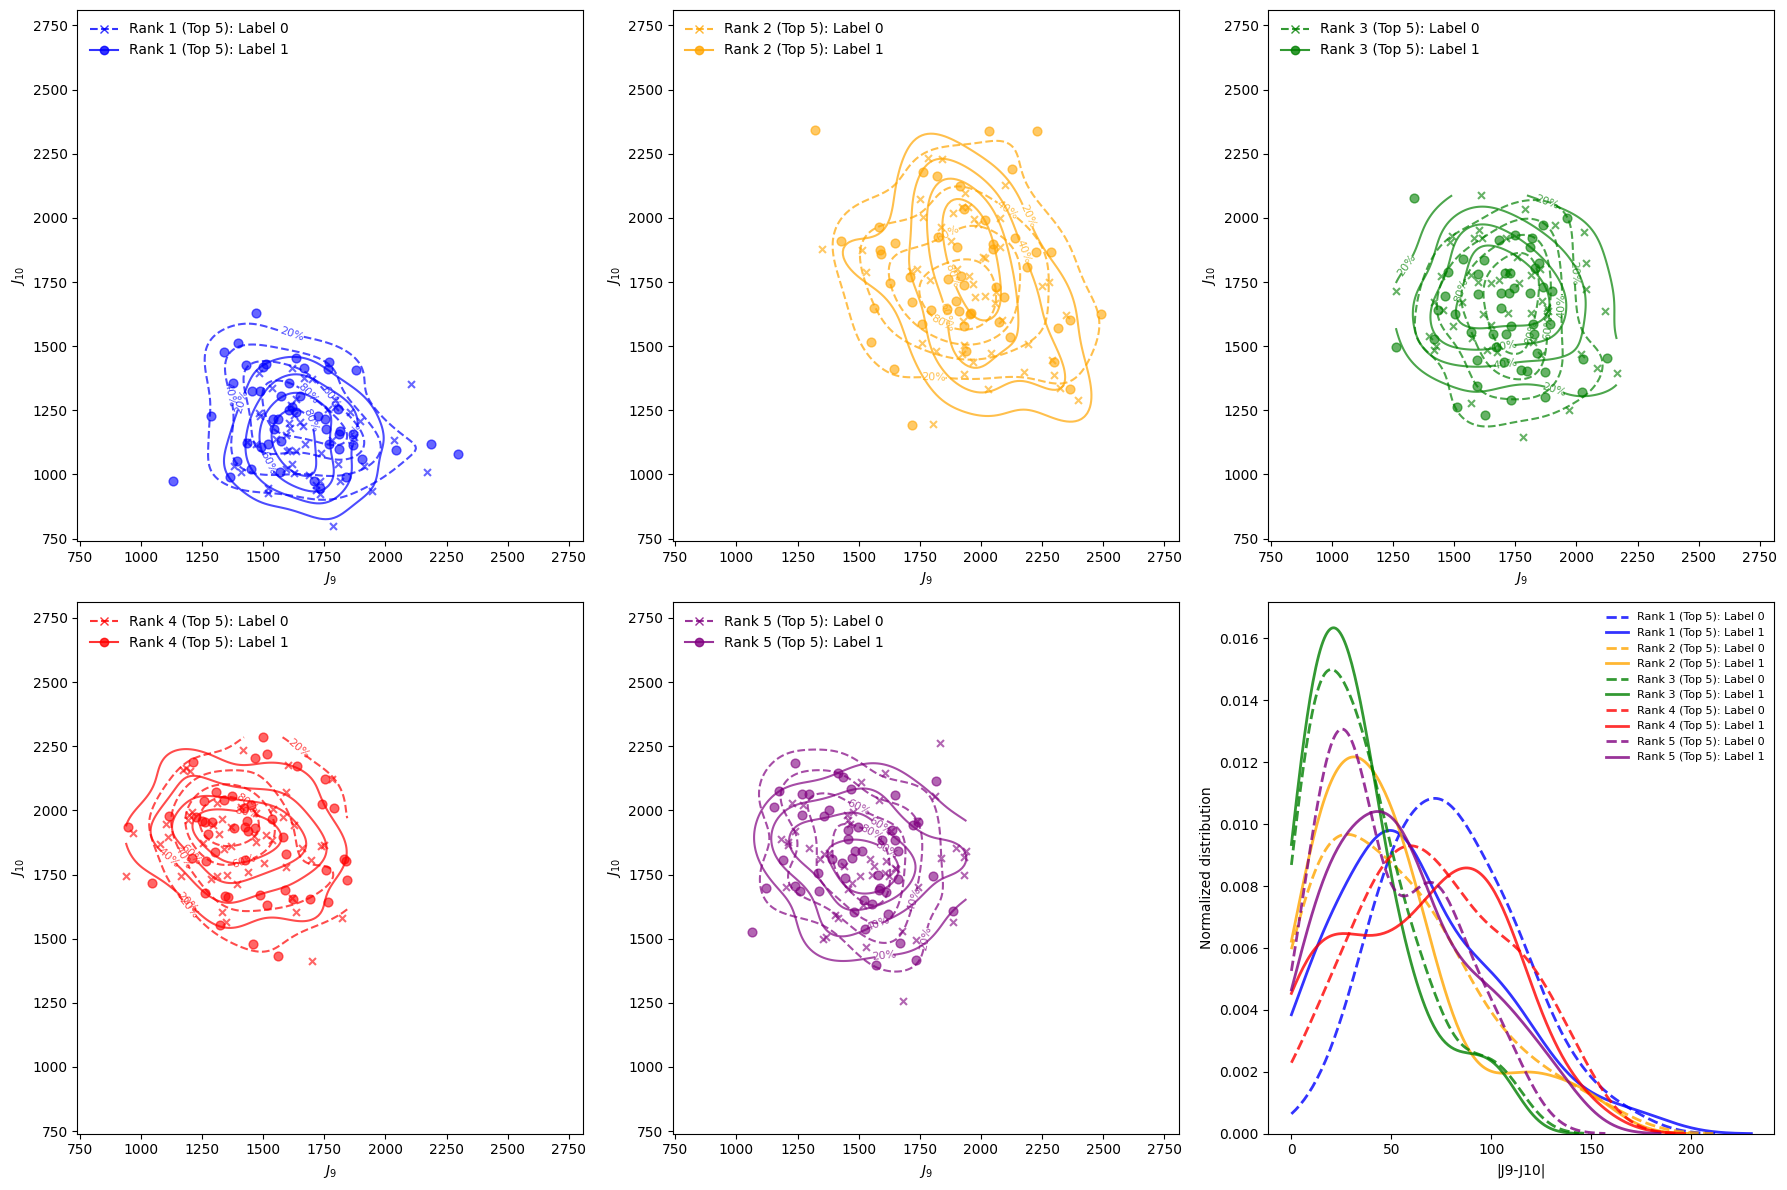

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

datasets = [hf1, hf2, hf3, hf4, hf5]
labels = [f"Rank {i} (Top 5)" for i in range(1, 6)]
base_colors = ['blue', 'orange', 'green', 'red', 'purple']
markers_1 = ['o', 'o', 'o', 'o', 'o']  # Symbols for Label 0: circle, square, triangle up, diamond, triangle down
markers_0 = ['x', 'x', 'x', 'x', 'x']  # Symbols for Label 1: x, plus, star, plus filled, X filled

# Create figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()  # Flatten to easily index

# Plot scatter plots with KDE contours (first 5 subplots)
for idx, (df, label, base_color, marker0, marker1) in enumerate(zip(datasets, labels, base_colors, markers_0, markers_1)):
    ax = axes[idx]
    x = df.iloc[:, 8].values * 6.95
    y = df.iloc[:, 9].values * 6.95
    
    # Use base_color and different markers for each dataset
    scatter0 = ax.scatter(x[50:], y[50:], s=25, alpha=0.6, color=base_color, marker=marker0)
    scatter1 = ax.scatter(x[:50], y[:50], s=40, alpha=0.6, color=base_color, marker=marker1)
    
    kde1 = gaussian_kde(np.vstack([x[:50], y[:50]]))
    kde0 = gaussian_kde(np.vstack([x[50:], y[50:]]))
    
    xmin, xmax = x.min() - 0.5, x.max() + 0.5
    ymin, ymax = y.min() - 0.5, y.max() + 0.5
    
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    
    # Label 0 contour - solid line
    Z0 = kde0(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled0 = Z0 / Z0.max() * 100
    CS0 = ax.contour(X, Y, Z_scaled0, levels=5, colors=base_color, linewidths=1.5, linestyles='solid', alpha=0.7)
    ax.clabel(CS0, inline=True, fontsize=8, fmt='%.0f%%')
    
    # Label 1 contour - dashed line
    Z1 = kde1(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z_scaled1 = Z1 / Z1.max() * 100
    CS1 = ax.contour(X, Y, Z_scaled1, levels=5, colors=base_color, linewidths=1.5, linestyles='dashed', alpha=0.7)
    ax.clabel(CS1, inline=True, fontsize=8, fmt='%.0f%%')
    
    # Create custom legend handles combining scatter and contour
    legend_handles = [
        (Line2D([0], [0], color=base_color, linestyle='dashed', linewidth=1.5),
         Line2D([0], [0], marker=marker0, color=base_color, linestyle='None', markersize=6, alpha=0.6)),
        (Line2D([0], [0], color=base_color, linestyle='solid', linewidth=1.5),
         Line2D([0], [0], marker=marker1, color=base_color, linestyle='None', markersize=6, alpha=0.6))
    ]
    
    # Custom legend with both marker and line
    custom_handles = [
        Line2D([0], [0], marker=marker0, color=base_color, linestyle='dashed', linewidth=1.5, markersize=6, alpha=0.8, label=f'{label}: Label 0'),
        Line2D([0], [0], marker=marker1, color=base_color, linestyle='solid', linewidth=1.5, markersize=6, alpha=0.8, label=f'{label}: Label 1')
    ]
    
    ax.legend(framealpha=0.0,handles=custom_handles, loc='upper left')
    ax.set_xlabel(r'$J_{9}$')
    ax.set_ylabel(r'$J_{10}$')
    ax.set_xlim((740, 2810))
    ax.set_ylim((740, 2810))
    #ax.set_title(f'KDE contour for {label} heat flux')

# Plot KDE difference plot (6th subplot)
output = pd.DataFrame({
    f"col{i+1}": np.sqrt((df.iloc[:, 8] - df.iloc[:, 9])**2)
    for i, df in enumerate(datasets)
})

ax = axes[5]
for i, (label, base_color) in enumerate(zip(labels, base_colors)):
    # Label 0 (next 50 rows) - dashed line
    sns.kdeplot(output[f"col{i+1}"].iloc[50:], 
                clip=(0, None), 
                label=f'{label}: Label 0', 
                color=base_color,
                fill=False,
                linewidth=2,
                linestyle='--',
                alpha=0.8,
                ax=ax)
    # Label 1 (first 50 rows) - solid line
    sns.kdeplot(output[f"col{i+1}"].iloc[:50], 
                clip=(0, None), 
                label=f'{label}: Label 1', 
                color=base_color, 
                fill=False,
                linewidth=2,
                linestyle='-',
                alpha=0.8,
                ax=ax)

ax.set_xlabel('|J9-J10|')
ax.set_ylabel('Normalized distribution')
ax.legend(framealpha=0.0, loc='best', fontsize=8)
#ax.set_title('Distribution of |J9-J10|')

plt.tight_layout()
plt.show()
# fig.savefig("combined_figure.pdf", format="pdf")